# How to Run Qukit-learn Algorithms with Benchmark Datasets

## 0. Introduction
Through this notebook, we introduce how to run the following five algorithms of qukit-learn using benchmark datasets provided by [Clustering Benchmarks](https://clustering-benchmarks.gagolewski.com/index.html).

- Combinatorial Clustering
- Consensus Clustering
- Constrained Clustering
- Kernel Clustering
- SVC

Please note that the benchmark dataset will be downloaded to the following path when running this notebook:

`./github.com/gagolews/clustering-data-v1/raw/v1.1.0/`

## 1. Preparation for Using Benchmarks

### 1.1 Import Libraries

In [1]:
from qklearn.cluster import CombinatorialClustering, ConsensusClustering, ConstrainedClustering, KernelClustering
from qklearn.svm import SVC as QSVC
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.svm import SVC as SSVC
from sklearn.metrics import accuracy_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from scipy.spatial import distance

import clustbench  # for using benchmarks
import matplotlib.pyplot as plt
import numpy as np

# for using Fixstars Amplify SDK
from amplify import FixstarsClient
from datetime import timedelta
from qklearn.utils import read_token

### 1.2 Set up Fixstars Amplify SDK
Note: Please place `amplify-license.yaml` in the same directory as this notebook in advance.

In [2]:
client = FixstarsClient()
# client.token = read_token("Fixstars")
client.token = "AE/v3y70tGeBESPhTEfABukYo9rLAcHHsmk"
client.parameters.timeout = timedelta(milliseconds=10000)

### 1.3 Define Methods for Plotting Results and for Evaluation
- A method for plotting results.

In [3]:
def plot_results(title, inputs, targets):
    scatter = plt.scatter(inputs[:,0], inputs[:,1], c=targets, cmap='Accent')
    plt.title(title)

    # create a legend with unique labels
    handles = []
    labels = []
    for label in set(targets):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                                markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
        labels.append(f'Cluster {label}')
    plt.legend(handles=handles, title="Cluster Labels")
    plt.show()

- A method for calculating the sum of distances within a cluster

In [4]:
def cost(data, label):
    dist = distance.squareform(distance.pdist(data))

    leng = len(data)
    cost = sum(
        [
            dist[i,j]
            for i in range(0,leng)
            for j in range(i+1,leng)
            if label[i] == label[j]
        ]
    )
    return cost

- A method for evaluating results from qukit-learn and scikit-learn

In [5]:
def eval_results(X, label_correct, label_qklearn, label_sklearn):
    print("+++ ARI +++")
    print(f"qukit-learn  : {adjusted_rand_score(label_correct, label_qklearn)}")
    print(f"scikit-learn : {adjusted_rand_score(label_correct, label_sklearn)}")
    print()

    print("+++ NMI +++")
    print(f"qukit-learn  : {normalized_mutual_info_score(label_correct, label_qklearn)}")
    print(f"scikit-learn : {normalized_mutual_info_score(label_correct, label_sklearn)}")
    print()

    print("+++ Sum of Distances within a Cluster +++")
    print(f"qukit-learn  : {cost(X, label_qklearn)}")
    print(f"scikit-learn : {cost(X, label_sklearn)}")
    print()

In [ ]:
#Run above cells

## 2. Execution of Qukit-learn Algorithms with Benchmarks 

### 2.1 Combinatorial Clustering

#### 2.1.1 Prepare the Benchmark Dataset

inputs.shape = (1000, 2)


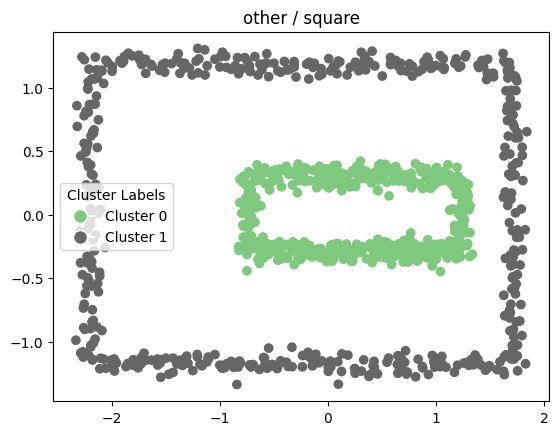

In [25]:
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"
dataset_ccl = clustbench.load_dataset("other", "square", url=data_url)
inputs = dataset_ccl.data
n_clusters = dataset_ccl.n_clusters[0]
label_correct = dataset_ccl.labels[0] - 1

print(f"inputs.shape = {inputs.shape}")
title = dataset_ccl.battery + " / " + dataset_ccl.dataset
plot_results(title, inputs, label_correct)

# wut / x1

#### 2.1.2 Execute Combinatorial Clustering with the Benchmark Dataset

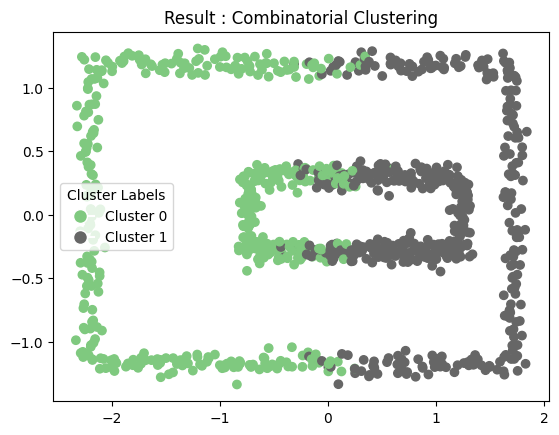

In [26]:
ccl = CombinatorialClustering(n_clusters=n_clusters)
ccl.fit(inputs)
label_ccl = ccl.predict(client)

plot_results("Result : Combinatorial Clustering", inputs, label_ccl)

#### 2.1.3 Compare with the Results from Scikit-learn Algorithm

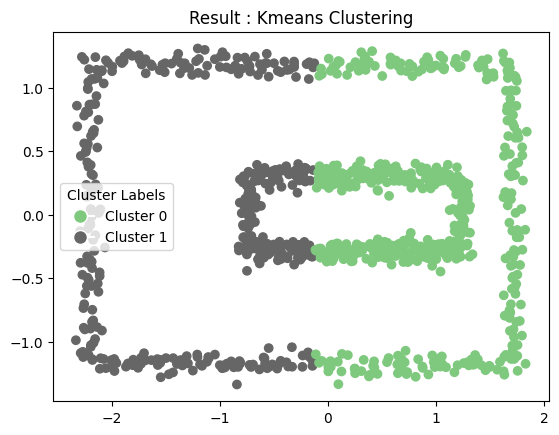

In [27]:
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(inputs)
label_kmeans = kmeans.labels_
plot_results("Result : Kmeans Clustering", inputs, label_kmeans)

In [28]:
eval_results(inputs, label_correct, label_ccl, label_kmeans)

+++ ARI +++
qukit-learn  : 0.023991270034095923
scikit-learn : 0.027942417220625456

+++ NMI +++
qukit-learn  : 0.018192821095032775
scikit-learn : 0.021418071430417233

+++ Sum of Distances within a Cluster +++
qukit-learn  : 315041.28306738875
scikit-learn : 311074.1470669631



### 2.2 Consensus Clustering

#### 2.2.1 Prepare the Benchmark Dataset

inputs.shape = (1000, 2)


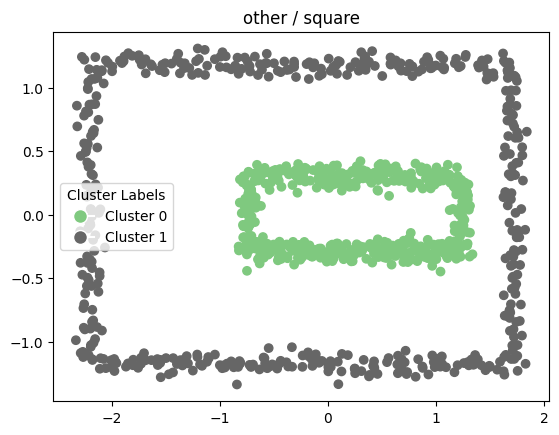

In [10]:
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"
dataset_cons = clustbench.load_dataset("other", "square", url=data_url)
inputs = dataset_cons.data
n_clusters = dataset_cons.n_clusters[0]
label_correct = dataset_cons.labels[0] - 1

print(f"inputs.shape = {inputs.shape}")
title = dataset_cons.battery + " / " + dataset_cons.dataset
plot_results(title, inputs, label_correct)

# wut / mk1

#### 2.2.2 Execute Consensus Clustering with the Benchmark Dataset

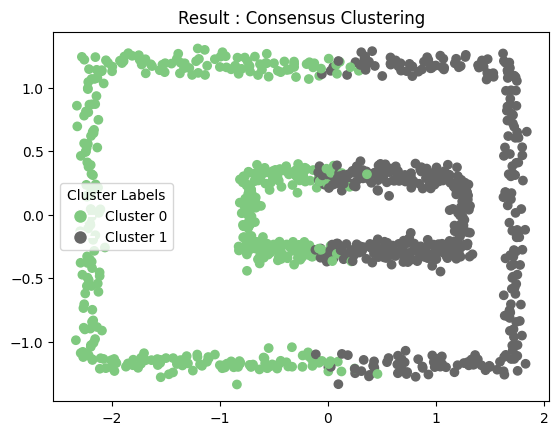

In [11]:
ccl = CombinatorialClustering(n_clusters=n_clusters)
label_ccl = ccl.fit_predict(inputs, client)

kmeans = KMeans(n_clusters=n_clusters)
label_kmeans = kmeans.fit_predict(inputs)

result = [label_ccl, label_kmeans]
    
conscl = ConsensusClustering(n_clusters=n_clusters, model="pairwise_similarity-based")

label_conscl = conscl.fit_predict(result, client)
plot_results("Result : Consensus Clustering", inputs, label_conscl)

#### 2.2.3 Compare with the Results from Scikit-learn Algorithm

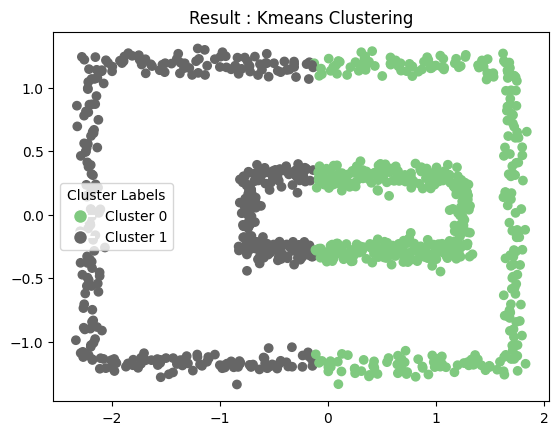

In [12]:
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(inputs)
label_kmeans = kmeans.labels_
plot_results("Result : Kmeans Clustering", inputs, label_kmeans)

In [13]:
eval_results(inputs, label_correct, label_conscl, label_kmeans)

+++ ARI +++
qukit-learn  : 0.026584045631148218
scikit-learn : 0.02726624576135215

+++ NMI +++
qukit-learn  : 0.020039075998489347
scikit-learn : 0.02092942958481101

+++ Sum of Distances within a Cluster +++
qukit-learn  : 310972.82515470363
scikit-learn : 311265.4161734202



### 2.3 Constrained Clustering

#### 2.3.1 Prepare the Benchmark Dataset

inputs.shape = (312, 2)


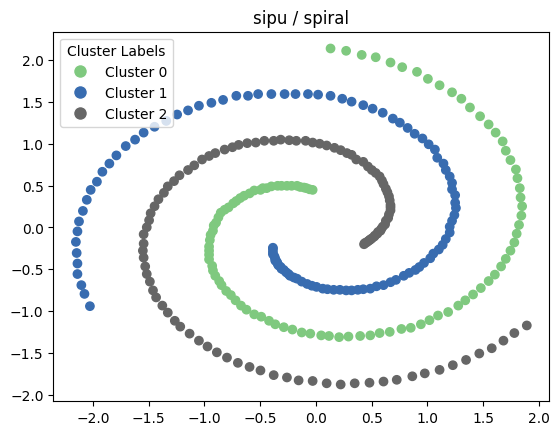

In [39]:
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"
dataset_constcl = clustbench.load_dataset("sipu", "spiral", url=data_url)
inputs = dataset_constcl.data
n_clusters = dataset_constcl.n_clusters[0]
label_correct = dataset_constcl.labels[0] - 1

print(f"inputs.shape = {inputs.shape}")
title = dataset_constcl.battery + " / " + dataset_constcl.dataset
plot_results(title, inputs, label_correct)

# wut / circles

#### 2.3.2 Execute Constrained Clustering with the Benchmark Dataset

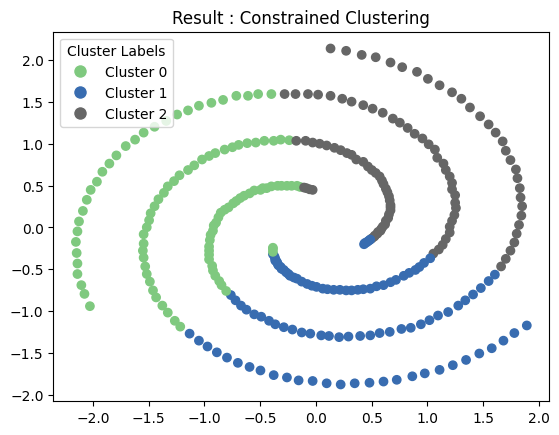

In [40]:
constcl = ConstrainedClustering(n_clusters=n_clusters)
constcl.fit(inputs)
constcl.add_balanced_sizes_to_qubo()
label_constcl = constcl.predict(client)

plot_results("Result : Constrained Clustering", inputs, label_constcl)

#### 2.3.3 Compare with the Results from Scikit-learn Algorithm

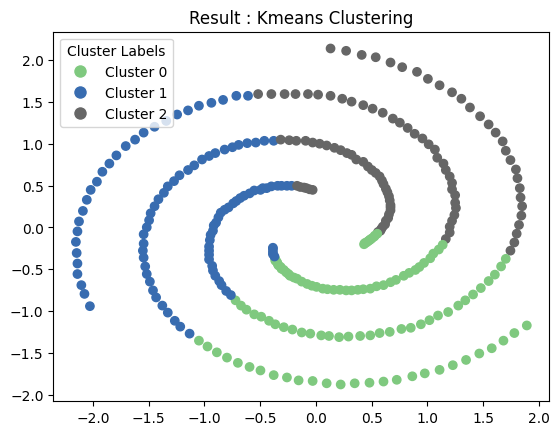

In [41]:
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(inputs)
label_kmeans = kmeans.labels_
plot_results("Result : Kmeans Clustering", inputs, label_kmeans)

In [42]:
eval_results(inputs, label_correct, label_constcl, label_kmeans)

+++ ARI +++
qukit-learn  : -0.005477916829904699
scikit-learn : -0.005689788008649467

+++ NMI +++
qukit-learn  : 0.0008909927802082984
scikit-learn : 0.000674739734558408

+++ Sum of Distances within a Cluster +++
qukit-learn  : 17965.0584860715
scikit-learn : 17980.93911473911



### 2.4 Kernel Clustering

#### 2.4.1 Prepare the Benchmark Dataset

inputs.shape = (240, 2)


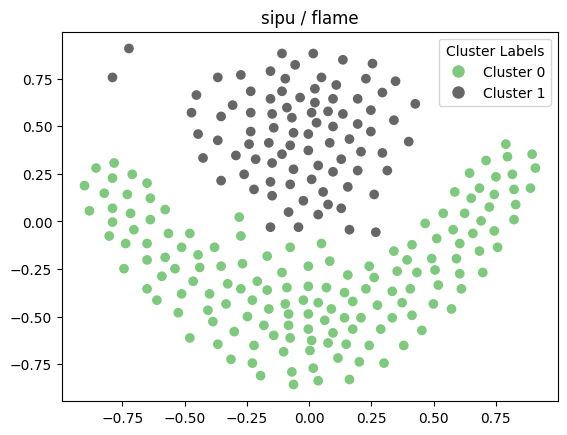

In [12]:
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"
dataset_kcl = clustbench.load_dataset("sipu", "flame", url=data_url)
inputs = dataset_kcl.data
n_clusters = dataset_kcl.n_clusters[0]
label_correct = dataset_kcl.labels[0] - 1

print(f"inputs.shape = {inputs.shape}")
title = dataset_kcl.battery + " / " + dataset_kcl.dataset
plot_results(title, inputs, label_correct)

#### 2.4.2 Execute Kernel Clustering with the Benchmark Dataset

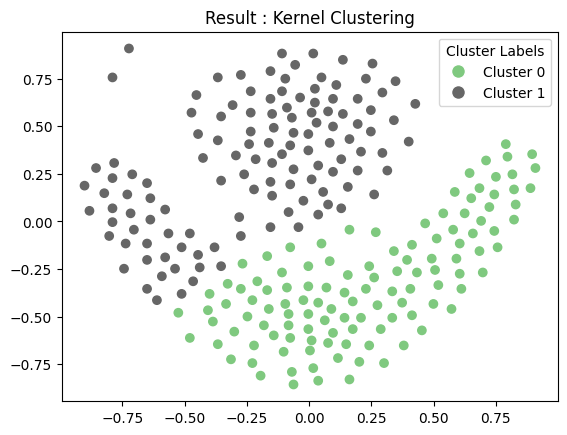

In [25]:
kcl = KernelClustering(n_clusters=n_clusters)
label_kcl = kcl.fit_predict(inputs, client)
plot_results("Result : Kernel Clustering", inputs, label_kcl)

#### 2.4.3 Compare with the Results from Scikit-learn Algorithm

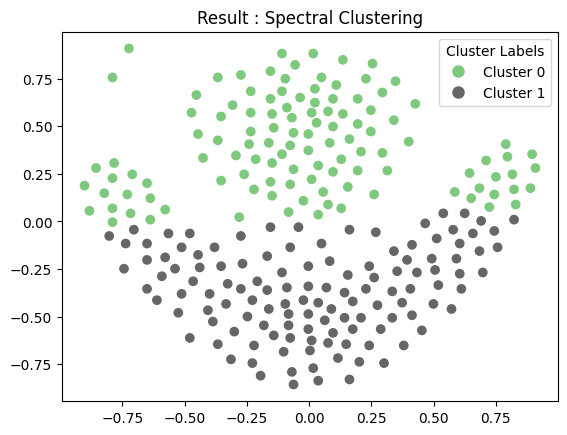

In [26]:
scl = SpectralClustering(n_clusters=n_clusters)
scl.fit(inputs)
label_scl = scl.labels_
plot_results("Result : Spectral Clustering", inputs, label_scl)

In [27]:
eval_results(inputs, label_correct, label_kcl, label_scl)

+++ ARI +++
qukit-learn  : 0.45350042255159556
scikit-learn : 0.4879557881626009

+++ NMI +++
qukit-learn  : 0.4461610743123011
scikit-learn : 0.44204779980920944

+++ Sum of Distances within a Cluster +++
qukit-learn  : 8488.088107884016
scikit-learn : 8544.418205140573



### 2.5 SVC

#### 2.5.1 Prepare the Benchmark Dataset

inputs.shape = (1016, 2)


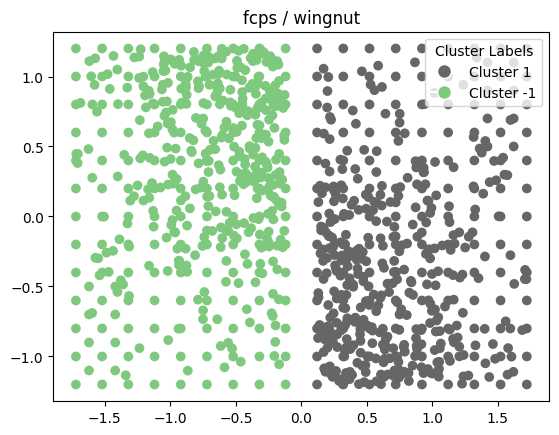

In [28]:
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"
dataset_svc = clustbench.load_dataset("fcps", "wingnut", url=data_url)
inputs = dataset_svc.data
n_clusters = dataset_svc.n_clusters[0]
label_correct = dataset_svc.labels[0]
label_correct[label_correct == 2] = -1

print(f"inputs.shape = {inputs.shape}")
title = dataset_svc.battery + " / " + dataset_svc.dataset
plot_results(title, inputs, label_correct)

- 問題点15の関係で、訓練用データが100、テスト用データが50になるように調整しました

In [29]:
X_train, X_test, t_train, t_test = train_test_split(inputs, label_correct, stratify=label_correct, train_size=100, test_size=50)

X_train.shape = (100, 2)


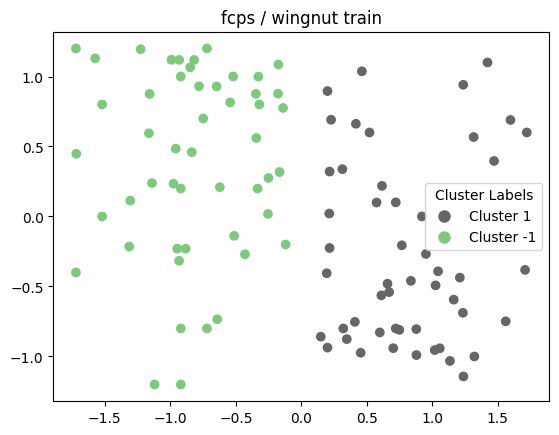

In [30]:
print(f"X_train.shape = {X_train.shape}")
title = dataset_svc.battery + " / " + dataset_svc.dataset + " train"
plot_results(title, X_train, t_train)

X_test.shape = (50, 2)


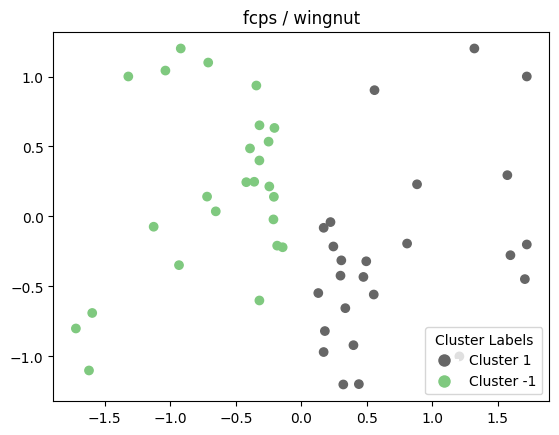

In [31]:
print(f"X_test.shape = {X_test.shape}")
title = dataset_svc.battery + " / " + dataset_svc.dataset
plot_results(title, X_test, t_test)

#### 2.5.2 Execute SVC with the Benchmark Dataset

- Calculate the accuracy score using SVC of scikit-learn

In [32]:
ssvc = SSVC()
ssvc.fit(X_train, t_train)

y_train_pred_slr = ssvc.predict(X_train)
y_test_pred_slr = ssvc.predict(X_test)

acc_sc = accuracy_score(t_test, y_test_pred_slr)
print(acc_sc)

1.0


- Sweep the parameters

RuntimeError: exceptions were raised from solve() of the Fixstars Amplify SDK

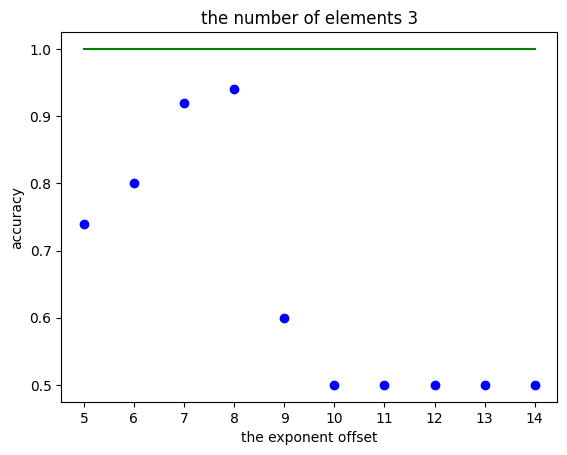

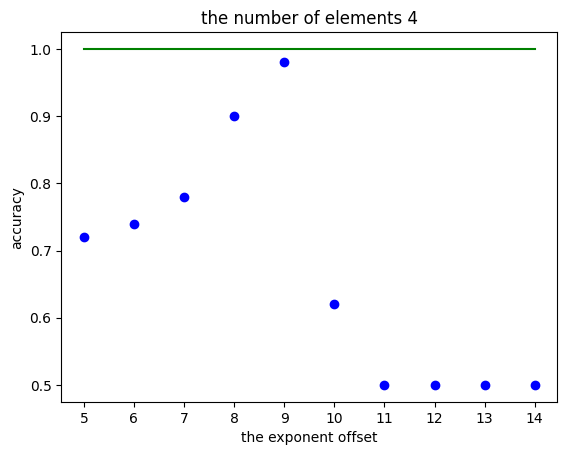

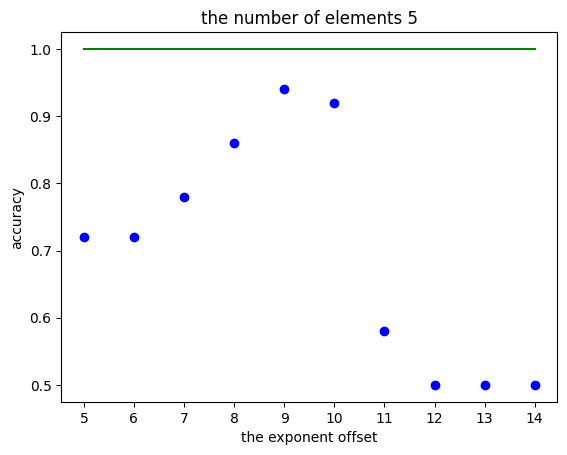

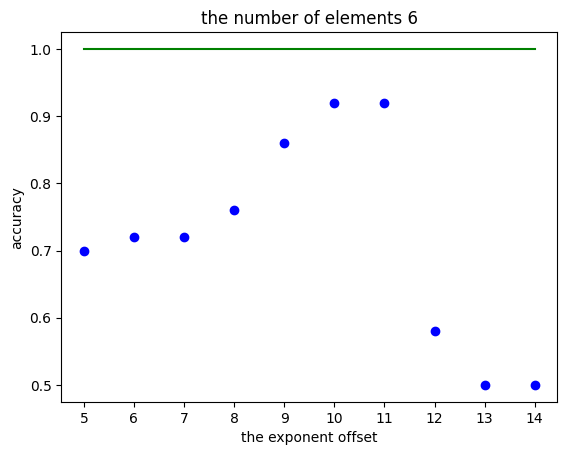

In [33]:
acc_max = 0
k_max = 0
e_max = 0
list_exponent_offset = list(range(5, 15))

for k in range(3, 10):
  acc = np.zeros(10)
  for i, e in enumerate(list_exponent_offset):
    model = QSVC()
    model.fit(X_train, t_train, client, num_elements=k, exponent_offset=e, xi=1)
    y_pred = model.predict(X_test)
    acc[i] = accuracy_score(t_test, y_pred)
    if acc_max <= acc[i]:
      acc_max = acc[i]
      k_max = k
      e_max = e

  fig = plt.figure()
  ax = fig.add_subplot(111)
  ax.set_title("the number of elements "+ str(k))
  ax.set_xlabel("the exponent offset")
  ax.set_ylabel("accuracy")
  ax.set_xticks(list_exponent_offset)
  ax.scatter(list_exponent_offset, acc, c ='blue')
  ax.plot(list_exponent_offset, np.full(10, acc_sc), c='green')

print("k_max ", k_max, ", e_max ", e_max, ", acc_max ", acc_max)

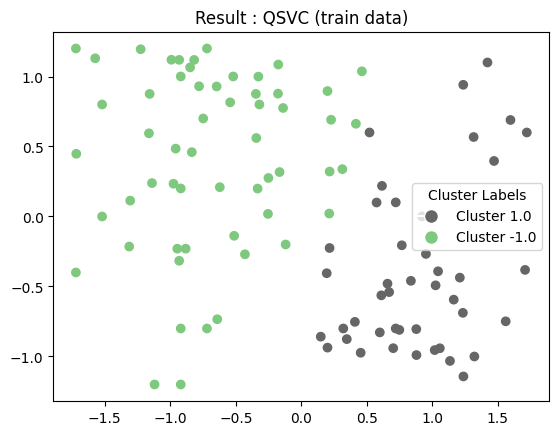

In [34]:
qsvc = QSVC()
qsvc.fit(X_train, t_train, client, num_elements=k_max, exponent_offset=e_max, xi=1)

# predict using the created model (for training and validation data)
y_train_pred_qlr = qsvc.predict(X_train)
y_test_pred_qlr = qsvc.predict(X_test)

plot_results("Result : QSVC (train data)", X_train, y_train_pred_qlr)

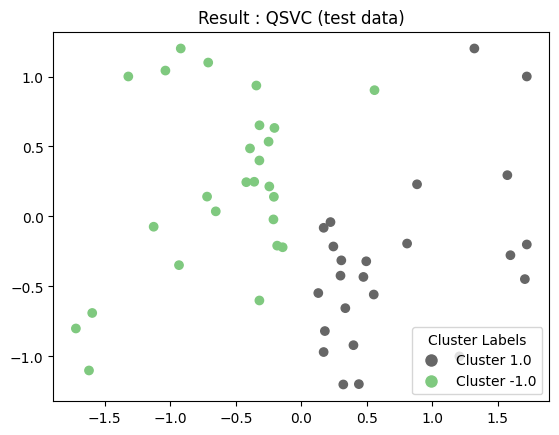

In [35]:
plot_results("Result : QSVC (test data)", X_test, y_test_pred_qlr)

#### 2.5.3 Compare with the Results from Scikit-learn Algorithm

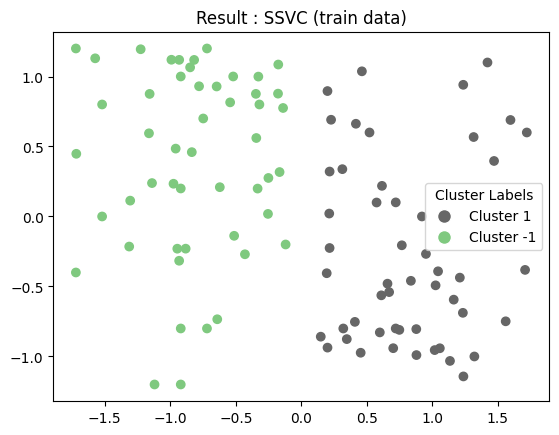

In [36]:
plot_results("Result : SSVC (train data)", X_train, y_train_pred_slr)

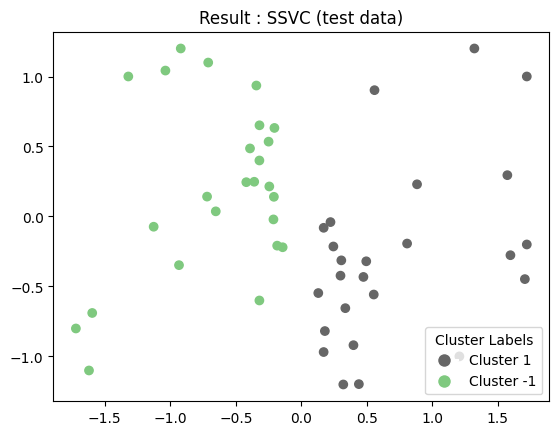

In [37]:
plot_results("Result : SSVC (test data)", X_test, y_test_pred_slr)

In [38]:
print("In the case of train data")
eval_results(X_train, t_train, y_train_pred_qlr, y_train_pred_slr)

In the case of train data
+++ ARI +++
qukit-learn  : 0.7369954580512469
scikit-learn : 1.0

+++ NMI +++
qukit-learn  : 0.698650799163015
scikit-learn : 1.0

+++ Sum of Distances within a Cluster +++
qukit-learn  : 2513.1169570756088
scikit-learn : 2444.9751876996356



In [50]:
print("In the case of test data")
eval_results(X_test, t_test, y_test_pred_qlr, y_test_pred_slr)

In the case of test data
+++ ARI +++
qukit-learn  : 0.7697076764107863
scikit-learn : 1.0

+++ NMI +++
qukit-learn  : 0.6770006327837452
scikit-learn : 1.0

+++ Sum of Distances within a Cluster +++
qukit-learn  : 604.6119867202023
scikit-learn : 616.1778023276212

